In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="darkgrid")
df = pd.read_csv("../data/raw/transactions.csv", parse_dates=["timestamp"])
print(df.shape)
df.head()

(1000, 9)


,transaction_id,timestamp,amount,merchant,category,country,hour,is_fraud,fraud_type
0,TXN923927,2024-01-01 07:53:00,41.02,ExxonMobil,gas,US,7,0,NaN
1,TXN642752,2024-01-01 12:25:00,125.22,Whole Foods,grocery,US,12,0,NaN
2,TXN722518,2024-01-01 14:06:00,13.61,Subway,restaurant,US,14,0,NaN
3,TXN594681,2024-01-02 08:32:00,60.24,Walmart,grocery,US,8,0,NaN
4,TXN938769,2024-01-02 11:14:00,102.99,ExxonMobil,gas,US,11,0,NaN


In [ ]:
df_model = df.copy()

le = LabelEncoder()
for col in ["merchant", "category", "country"]:
    df_model[col] = le.fit_transform(df_model[col])

# Descartar columnas que no sirven como features
df_model = df_model.drop(columns=["transaction_id", "timestamp", "fraud_type"])

# X = variables de entrada, y = lo que el modelo predice
X = df_model.drop(columns=["is_fraud"])
y = df_model["is_fraud"]

print("Features:", list(X.columns))
print("Fraud rate:", y.mean().round(3))
X.head()

Features: ['amount', 'merchant', 'category', 'country', 'hour']
Fraud rate: 0.05


,amount,merchant,category,country,hour
0,41.02,10,0,9,7
1,125.22,26,1,9,12
2,13.61,21,3,9,14
3,60.24,25,1,9,8
4,102.99,10,0,9,11


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print("Model trained successfully.")

Training samples: 800
Test samples: 200
Model trained successfully.


=== Classification Report ===
              precision    recall  f1-score   support

       Legit       1.00      0.99      1.00       190
       Fraud       0.91      1.00      0.95        10

    accuracy                           0.99       200
   macro avg       0.95      1.00      0.97       200
weighted avg       1.00      0.99      1.00       200

ROC-AUC Score: 1.0000


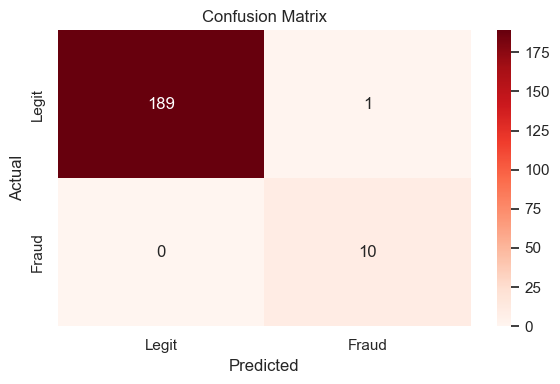

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Legit", "Fraud"],
            yticklabels=["Legit", "Fraud"])
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix.png", dpi=150)
plt.show()

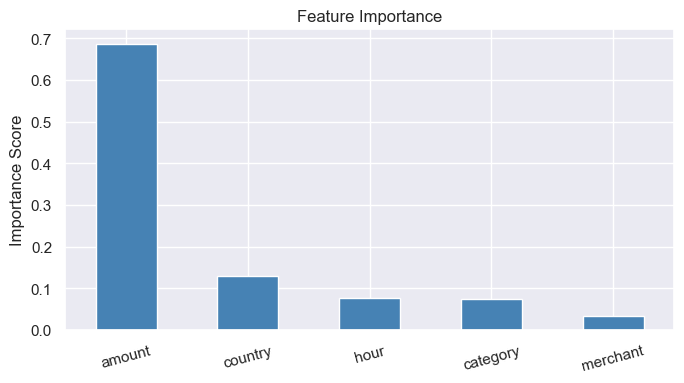

In [5]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind="bar", color="steelblue", ax=ax)
ax.set_title("Feature Importance")
ax.set_ylabel("Importance Score")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("../outputs/figures/feature_importance.png", dpi=150)
plt.show()